# Machine Learning algorithms on Nike Shorts & TikTok Insights 2025

**Operation performs** :
* Exploratory Data Analysis (EDA)
* Feature Engineering
* Logistic Regression (classification)
* Linear Regression (prediction)


## Importing Libraries

In [44]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,roc_curve,
    classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

## Loading Dataset

In [3]:
df = pd.read_csv("youtube_shorts_tiktok_trends_2025.csv")

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
display(df.head())

Shape: (48079, 58)

Columns:
 ['platform', 'country', 'region', 'language', 'category', 'hashtag', 'title_keywords', 'author_handle', 'sound_type', 'music_track', 'week_of_year', 'duration_sec', 'views', 'likes', 'comments', 'shares', 'saves', 'engagement_rate', 'trend_label', 'source_hint', 'notes', 'device_type', 'upload_hour', 'genre', 'trend_duration_days', 'trend_type', 'engagement_velocity', 'dislikes', 'comment_ratio', 'share_rate', 'save_rate', 'like_dislike_ratio', 'publish_dayofweek', 'publish_period', 'event_season', 'tags', 'sample_comments', 'creator_avg_views', 'creator_tier', 'season', 'publish_date_approx', 'year_month', 'title', 'title_length', 'has_emoji', 'avg_watch_time_sec', 'completion_rate', 'device_brand', 'traffic_source', 'is_weekend', 'row_id', 'engagement_total', 'like_rate', 'dislike_rate', 'engagement_per_1k', 'engagement_like_rate', 'engagement_comment_rate', 'engagement_share_rate']


,platform,country,region,language,category,hashtag,title_keywords,author_handle,sound_type,music_track,week_of_year,duration_sec,views,likes,comments,shares,saves,engagement_rate,trend_label,source_hint,notes,device_type,upload_hour,genre,trend_duration_days,trend_type,engagement_velocity,dislikes,comment_ratio,share_rate,save_rate,like_dislike_ratio,publish_dayofweek,publish_period,event_season,tags,sample_comments,creator_avg_views,creator_tier,season,publish_date_approx,year_month,title,title_length,has_emoji,avg_watch_time_sec,completion_rate,device_brand,traffic_source,is_weekend,row_id,engagement_total,like_rate,dislike_rate,engagement_per_1k,engagement_like_rate,engagement_comment_rate,engagement_share_rate
0,TikTok,Jp,Asia,ja,Gaming,#Lifestyle,Night Routine — College,NextVision,trending,8bit loop,1,40,252497,21755,3170,1977,3415,0.120069,rising,TikTok Creative Center,split-screen,Android,15,Lifestyle,4,Short,63124.25,1011,0.012555,0.007830,0.013525,21.497036,Saturday,Afternoon,Regular,"daily, lifestyle, motivation",ずっと見ちゃう😂,96474.3,Mid,Spring,2025-01-04,2025-01,Night Routine — Productivity 🏖️,31,1,25.8,0.645,iPhone,External,1,2e681528d17a1fe1986857942536ec27,30317,0.086159,0.004004,120.069,0.086159,0.012555,0.007830
1,TikTok,Se,Europe,sv,Food,#Sports,Morning Routine — College,DailyVlogsDiego,trending,Street vibe,1,18,270580,23080,2124,2108,3265,0.113005,declining,TikTok Creative Center,greenscreen,Android,3,Sports,56,Evergreen,4831.79,655,0.007850,0.007791,0.012067,35.182927,Wednesday,Night,Regular,"gym, football, workout",This is fire 🔥,104638.4,Mid,Fall,2025-01-01,2025-01,Football skills in 60s 📱,24,1,10.4,0.578,iPhone,Search,0,2e35fa0b2978b9cae635839c1d4e9e74,30577,0.085298,0.002421,113.005,0.085298,0.007850,0.007791
2,TikTok,Za,Africa,en,Art,#Workout,Night Routine — College,BeyondHub,licensed,Gallery pad,1,22,7385,363,33,38,69,0.068111,seasonal,TikTok Creative Center,subtitles,Android,15,Sports,11,Medium,671.36,12,0.004469,0.005146,0.009343,27.923077,Sunday,Afternoon,Regular,"football, gym, workout",Instant like!,108139.9,Mid,Fall,2025-01-05,2025-01,Football skills in 60s,22,0,11.7,0.532,Huawei,External,1,0d88a011235a82244995ef52961f9502,503,0.049154,0.001625,68.111,0.049154,0.004469,0.005146
3,TikTok,Kr,Asia,ko,News,#Esports,Best Settings for Fortnite,NextHub,original,Neutral piano,1,36,72377,6243,811,383,391,0.108156,declining,Open Web Samples,cinematic b-roll,Android,15,Gaming,10,Medium,7237.70,229,0.011205,0.005292,0.005402,27.143478,Friday,Afternoon,SummerBreak,"fps, esports, clips, gaming, valorant, highlights",Can’t stop watching 😂,102133.2,Mid,Summer,2025-01-03,2025-01,Pro Tips for Valorant in 60s 🎮,30,1,23.7,0.658,Huawei,Search,1,e15cff7621ed3f9eb9d2c97c841be0f3,7828,0.086257,0.003164,108.156,0.086257,0.011205,0.005292
4,TikTok,Au,Oceania,en,Beauty,#Comedy,When your friend is Beginners,LucasOfficial,licensed,Soft glam loop,1,35,16174,832,68,67,204,0.072400,seasonal,TikTok Creative Center,text-to-speech,Android,18,Comedy,6,Short,2695.67,19,0.004204,0.004142,0.012613,41.600000,Saturday,Evening,Regular,"comedy, relatable, sketch",So underrated!,87549.4,Mid,Fall,2025-01-04,2025-01,POV: Budget 😂,13,1,24.6,0.703,Huawei,ForYou,1,d696b4f0a50ea70e7cb5021be7e198ec,1171,0.051441,0.001175,72.400,0.051441,0.004204,0.004142


# Data cleaning 

## Cleaned column names 

In [16]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print(df.columns.tolist())

['platform', 'country', 'region', 'language', 'category', 'hashtag', 'title_keywords', 'author_handle', 'sound_type', 'music_track', 'week_of_year', 'duration_sec', 'views', 'likes', 'comments', 'shares', 'saves', 'engagement_rate', 'trend_label', 'source_hint', 'notes', 'device_type', 'upload_hour', 'genre', 'trend_duration_days', 'trend_type', 'engagement_velocity', 'dislikes', 'comment_ratio', 'share_rate', 'save_rate', 'like_dislike_ratio', 'publish_dayofweek', 'publish_period', 'event_season', 'tags', 'sample_comments', 'creator_avg_views', 'creator_tier', 'season', 'publish_date_approx', 'year_month', 'title', 'title_length', 'has_emoji', 'avg_watch_time_sec', 'completion_rate', 'device_brand', 'traffic_source', 'is_weekend', 'row_id', 'engagement_total', 'like_rate', 'dislike_rate', 'engagement_per_1k', 'engagement_like_rate', 'engagement_comment_rate', 'engagement_share_rate']


## Basic info

In [4]:
print(df.info())

print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False))

print("\nDuplicate rows:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 48079 entries, 0 to 48078
Data columns (total 58 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   platform                 48079 non-null  str    
 1   country                  48079 non-null  str    
 2   region                   48079 non-null  str    
 3   language                 48079 non-null  str    
 4   category                 48079 non-null  str    
 5   hashtag                  48079 non-null  str    
 6   title_keywords           48079 non-null  str    
 7   author_handle            48079 non-null  str    
 8   sound_type               48079 non-null  str    
 9   music_track              48079 non-null  str    
 10  week_of_year             48079 non-null  int64  
 11  duration_sec             48079 non-null  int64  
 12  views                    48079 non-null  int64  
 13  likes                    48079 non-null  int64  
 14  comments                 48079 no

## Fix Date Type

In [5]:
numeric_candidates = [
    "duration_sec", "completion_rate", "engagement_velocity",
    "upload_hour", "avg_watch_time_sec", "week_of_year"
]

for col in numeric_candidates:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Optional cleanup for binary field
if "has_emoji" in df.columns:
    if df["has_emoji"].dtype == "object":
        df["has_emoji"] = (
            df["has_emoji"]
            .astype(str)
            .str.strip()
            .str.lower()
            .map({"yes": 1, "no": 0, "true": 1, "false": 0, "1": 1, "0": 0}))

# Exploratory Data Analysis (EDA) Steps

## EDA: overview

In [6]:
print("\nNumeric summary:")
display(df.describe(include=[np.number]).T)

print("\nCategorical summary:")
display(df.describe(include=["object", "category"]).T)


Numeric summary:


,count,mean,std,min,25%,50%,75%,max
week_of_year,48079.0,18.234260,9.996924,1.000000,10.000000,18.000000,27.000000,3.500000e+01
duration_sec,48079.0,34.489320,16.401608,5.000000,22.000000,31.000000,43.000000,9.000000e+01
views,48079.0,99292.760894,131852.208725,794.000000,30322.500000,59620.000000,118094.500000,3.080686e+06
likes,48079.0,5737.732108,8639.923653,33.000000,1526.000000,3167.000000,6618.000000,3.109160e+05
comments,48079.0,628.657314,967.782704,3.000000,160.000000,339.000000,720.000000,3.177600e+04
shares,48079.0,553.484494,849.436172,3.000000,143.000000,301.000000,635.000000,2.900400e+04
saves,48079.0,591.071487,978.280616,2.000000,138.000000,301.000000,659.500000,2.967900e+04
engagement_rate,48079.0,0.075415,0.030091,0.014720,0.052326,0.071575,0.094794,2.358190e-01
upload_hour,48079.0,15.986751,5.489399,0.000000,13.000000,17.000000,20.000000,2.300000e+01
trend_duration_days,48079.0,13.742923,13.343582,3.000000,5.000000,7.000000,17.000000,6.000000e+01



Categorical summary:


C:\Users\Atul soni\AppData\Local\Temp\ipykernel_1468\214761611.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=["object", "category"]).T)


,count,unique,top,freq
platform,48079,2,TikTok,28844
country,48079,30,Ke,1699
region,48079,6,Europe,16121
language,48079,19,en,9542
category,48079,19,Pets,2626
hashtag,48079,41,#FYP,11902
title_keywords,48079,137,Makeup basics you need,1270
author_handle,48079,720,VividLabs,228
sound_type,48079,3,original,16102
music_track,48079,61,HIIT drums,902


## EDA: Missing Value

In [7]:
missing_df = df.isna().sum().reset_index()
missing_df.columns = ["column", "missing_count"]
display(missing_df.head(20))

,column,missing_count
0,platform,0
1,country,0
2,region,0
3,language,0
4,category,0
5,hashtag,0
6,title_keywords,0
7,author_handle,0
8,sound_type,0
9,music_track,0


## EDA: Numeric Distribution

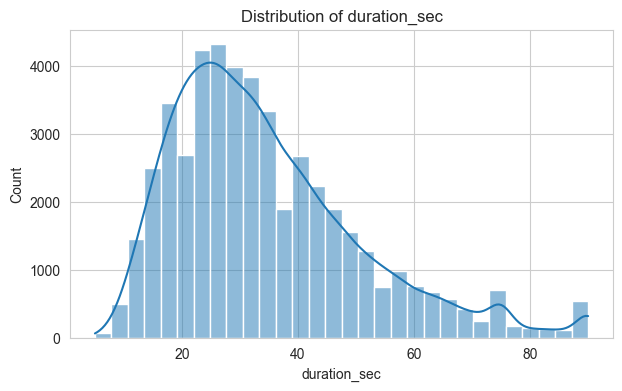

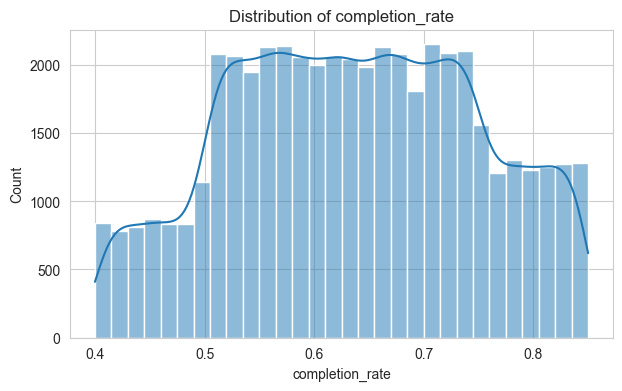

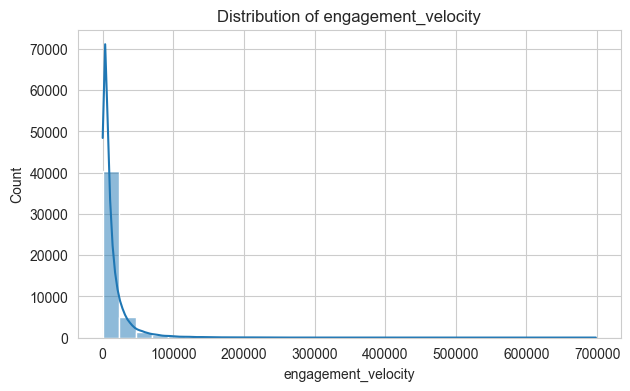

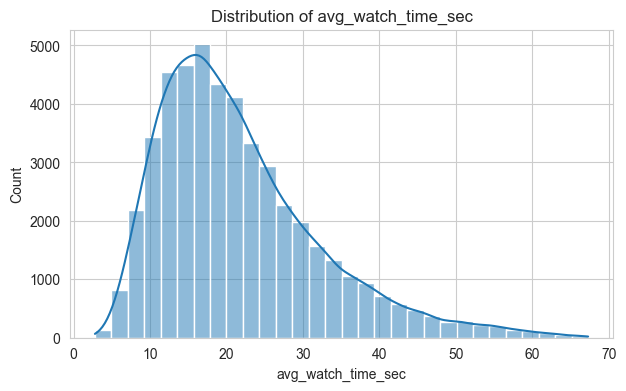

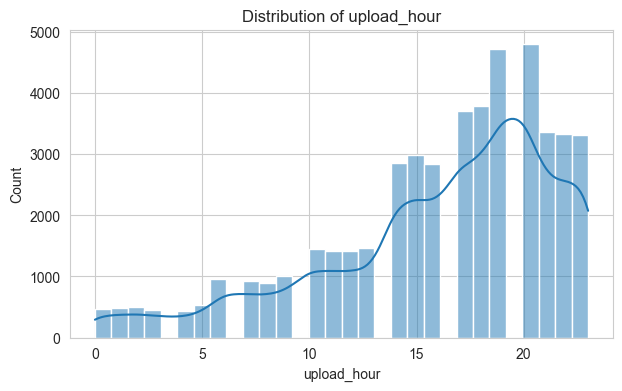

In [25]:
eda_num_cols = [col for col in ["duration_sec", "completion_rate", "engagement_velocity", "avg_watch_time_sec", "upload_hour"] if col in df.columns]

for col in eda_num_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()

## EDA: Categorical Distribution 

C:\Users\Atul soni\AppData\Local\Temp\ipykernel_15648\615381398.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_counts.values, y=top_counts.index, palette="magma")


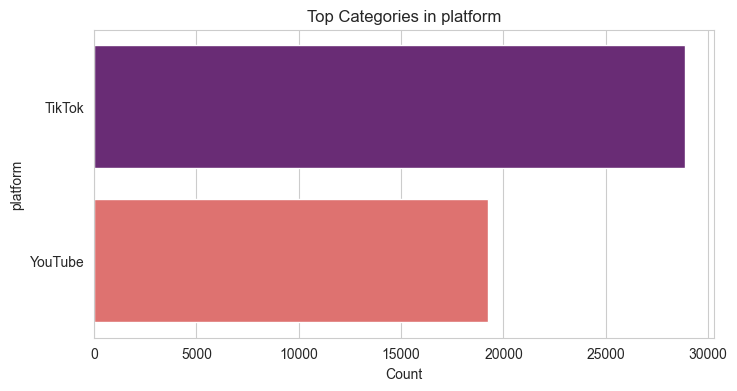

C:\Users\Atul soni\AppData\Local\Temp\ipykernel_15648\615381398.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_counts.values, y=top_counts.index, palette="magma")


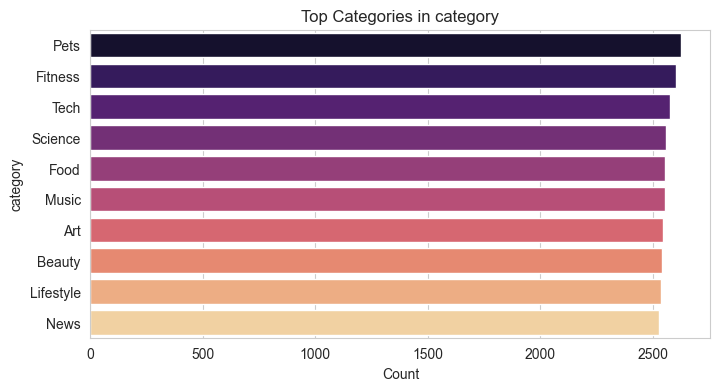

C:\Users\Atul soni\AppData\Local\Temp\ipykernel_15648\615381398.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_counts.values, y=top_counts.index, palette="magma")


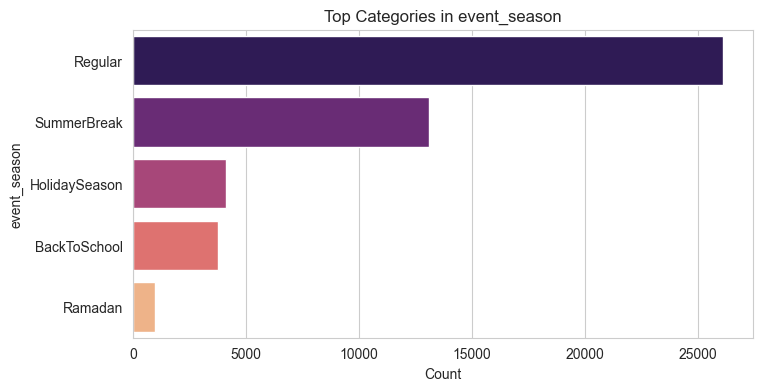

C:\Users\Atul soni\AppData\Local\Temp\ipykernel_15648\615381398.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_counts.values, y=top_counts.index, palette="magma")


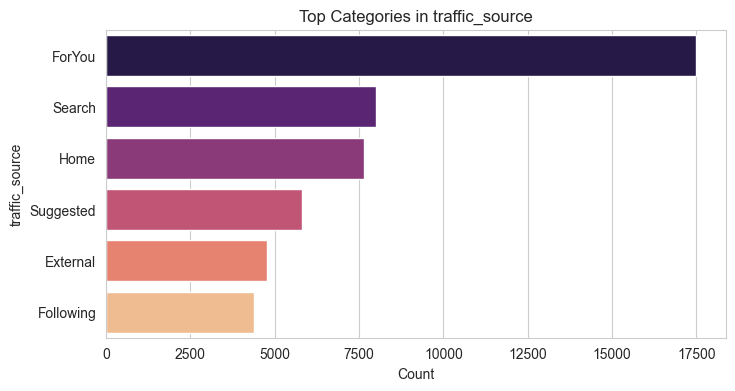

In [22]:
eda_cat_cols = [col for col in ["platform", "category", "event_season", "traffic_source"] if col in df.columns]

for col in eda_cat_cols:
    plt.figure(figsize=(8, 4))
    top_counts = df[col].astype(str).value_counts().head(10)
    sns.barplot(x=top_counts.values, y=top_counts.index, palette="magma")
    plt.title(f"Top Categories in {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.show()

## EDA: Correlation Heatmap

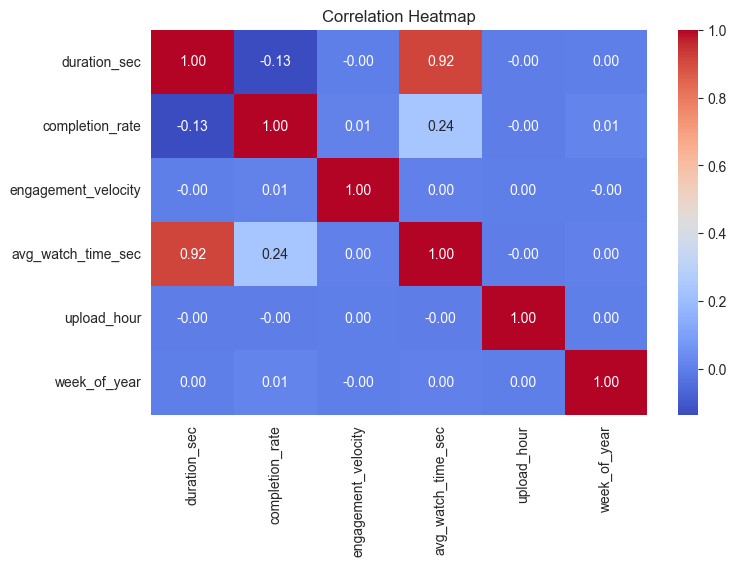

In [8]:
corr_cols = [col for col in ["duration_sec", "completion_rate", "engagement_velocity", "avg_watch_time_sec", "upload_hour", "week_of_year"] if col in df.columns]

if len(corr_cols) > 1:
    plt.figure(figsize=(8, 5))
    sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Heatmap")
    plt.show()

# Logistic Regression Model

## Setting Target for logistic regression 

In [36]:
required_for_label = ["completion_rate", "engagement_velocity", "avg_watch_time_sec", "duration_sec"]

for col in required_for_label:
    if col not in df.columns:
        raise ValueError(f"Required column missing for trend_label creation: {col}")

# Fill critical columns temporarily for score creation
df["completion_rate"] = df["completion_rate"].fillna(df["completion_rate"].median())
df["engagement_velocity"] = df["engagement_velocity"].fillna(df["engagement_velocity"].median())
df["avg_watch_time_sec"] = df["avg_watch_time_sec"].fillna(df["avg_watch_time_sec"].median())

df["duration_sec"] = df["duration_sec"].replace(0, np.nan)
df["duration_sec"] = df["duration_sec"].fillna(df["duration_sec"].median())

# Create watch ratio
df["watch_ratio"] = df["avg_watch_time_sec"] / df["duration_sec"]
df["watch_ratio"] = df["watch_ratio"].replace([np.inf, -np.inf], np.nan)
df["watch_ratio"] = df["watch_ratio"].fillna(df["watch_ratio"].median())

# Robust scaling by rank percentiles to reduce extreme-value impact
df["completion_rank"] = df["completion_rate"].rank(pct=True)
df["engagement_rank"] = df["engagement_velocity"].rank(pct=True)
df["watch_ratio_rank"] = df["watch_ratio"].rank(pct=True)

# Composite viral score
df["viral_score"] = (
    0.45 * df["completion_rank"] +
    0.40 * df["engagement_rank"] +
    0.15 * df["watch_ratio_rank"]
)

# Top 20% = viral
cutoff = df["viral_score"].quantile(0.80)
df["trend_label"] = (df["viral_score"] >= cutoff).astype(int)

print("trend_label distribution:")
print(df["trend_label"].value_counts())

trend_label distribution:
trend_label
0    38463
1     9616
Name: count, dtype: int64


## EDA for new target 

C:\Users\Atul soni\AppData\Local\Temp\ipykernel_1468\1247737431.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["trend_label"], palette="Set2")


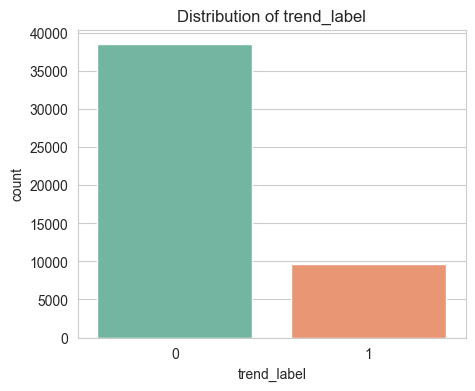

trend_label
0    0.799996
1    0.200004
Name: proportion, dtype: float64


In [37]:
plt.figure(figsize=(5, 4))
sns.countplot(x=df["trend_label"], palette="Set2")
plt.title("Distribution of trend_label")
plt.show()

print(df["trend_label"].value_counts(normalize=True))

## Features vs Trend Label

C:\Users\Atul soni\AppData\Local\Temp\ipykernel_1468\1999266770.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="trend_label", y=col, palette="pastel")


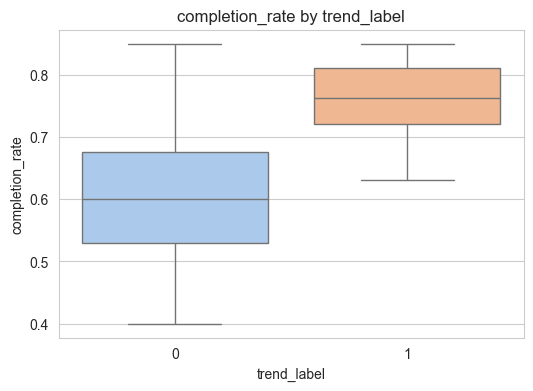

C:\Users\Atul soni\AppData\Local\Temp\ipykernel_1468\1999266770.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="trend_label", y=col, palette="pastel")


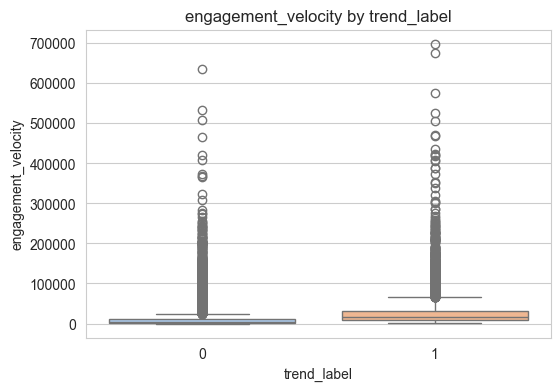

C:\Users\Atul soni\AppData\Local\Temp\ipykernel_1468\1999266770.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="trend_label", y=col, palette="pastel")


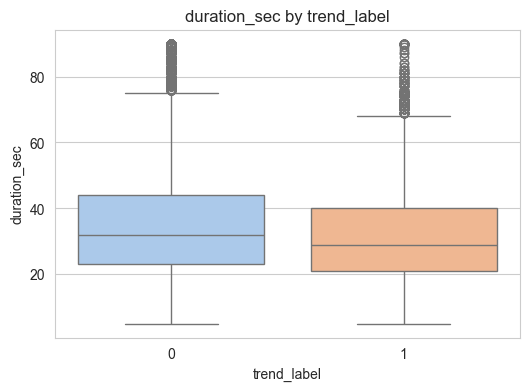

C:\Users\Atul soni\AppData\Local\Temp\ipykernel_1468\1999266770.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="trend_label", y=col, palette="pastel")


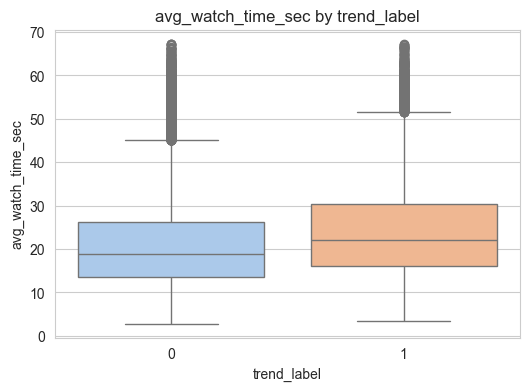

In [38]:
compare_cols = [col for col in ["completion_rate", "engagement_velocity", "duration_sec", "avg_watch_time_sec"] if col in df.columns]

for col in compare_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x="trend_label", y=col, palette="pastel")
    plt.title(f"{col} by trend_label")
    plt.show()

## Logistic Regression Data

In [11]:
logit_features = [
    "platform", "category", "duration_sec",
    "completion_rate", "engagement_velocity",
    "upload_hour", "has_emoji"
]

logit_features = [col for col in logit_features if col in df.columns]

logit_df = df[logit_features + ["trend_label"]].copy()

X_logit = logit_df[logit_features]
y_logit = logit_df["trend_label"]

print("Classes in y_logit:")
print(y_logit.value_counts())

Classes in y_logit:
trend_label
0    38463
1     9616
Name: count, dtype: int64


## Logistic Preprocessor

In [39]:
num_features_logit = [col for col in ["duration_sec", "completion_rate", "engagement_velocity", "upload_hour"] if col in X_logit.columns]
cat_features_logit = [col for col in ["platform", "category"] if col in X_logit.columns]
bin_features_logit = [col for col in ["has_emoji"] if col in X_logit.columns]

numeric_transformer_logit = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_logit = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_logit = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_logit, num_features_logit),
        ("cat", categorical_transformer_logit, cat_features_logit),
        ("bin", SimpleImputer(strategy="most_frequent"), bin_features_logit)
    ],
    remainder="drop"
)

## Train Logistic Regression

In [41]:
X_train_logit, X_test_logit, y_train_logit, y_test_logit = train_test_split(
    X_logit, y_logit, test_size=0.2, random_state=42, stratify=y_logit
)

logit_model = Pipeline(steps=[
    ("preprocess", preprocessor_logit),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

logit_model.fit(X_train_logit, y_train_logit)

y_pred_logit = logit_model.predict(X_test_logit)
y_proba_logit = logit_model.predict_proba(X_test_logit)[:, 1]

## evaluation of logistic regression model

Accuracy : 0.8973585690515807
Precision: 0.6737193763919822
Recall   : 0.9438377535101404
F1 Score : 0.7862248213125406
ROC AUC  : 0.9622005782350104

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.89      0.93      7693
           1       0.67      0.94      0.79      1923

    accuracy                           0.90      9616
   macro avg       0.83      0.91      0.86      9616
weighted avg       0.92      0.90      0.90      9616



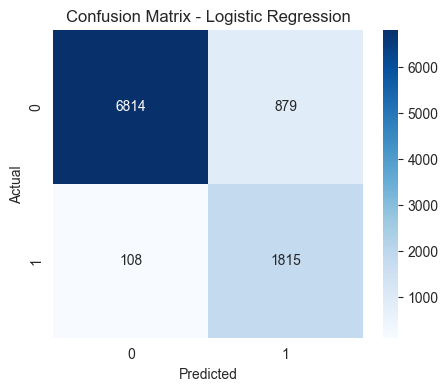

In [42]:
print("Accuracy :", accuracy_score(y_test_logit, y_pred_logit))
print("Precision:", precision_score(y_test_logit, y_pred_logit))
print("Recall   :", recall_score(y_test_logit, y_pred_logit))
print("F1 Score :", f1_score(y_test_logit, y_pred_logit))
print("ROC AUC  :", roc_auc_score(y_test_logit, y_proba_logit))

print("\nClassification Report:\n")
print(classification_report(y_test_logit, y_pred_logit))

cm = confusion_matrix(y_test_logit, y_pred_logit)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

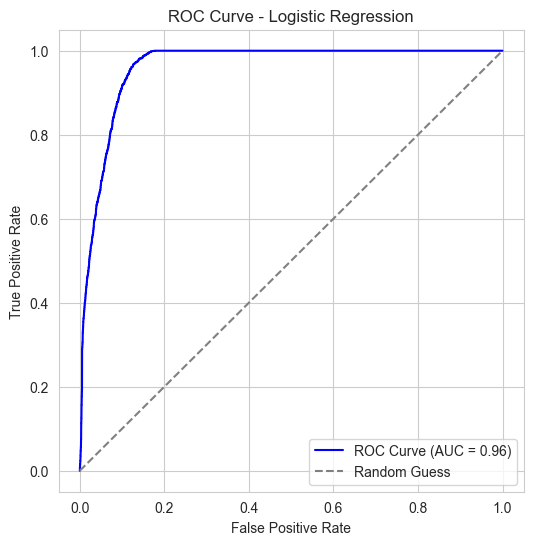

In [45]:
fpr, tpr, thresholds = roc_curve(y_test_logit, y_proba_logit)
roc_auc = roc_auc_score(y_test_logit, y_proba_logit)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color="blue", label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.show()

# linear Regression Model

## Linear Regression Dataset

In [21]:
lin_features = [
    "duration_sec", "avg_watch_time_sec",
    "platform", "category", "event_season", "traffic_source",
    "engagement_velocity", "upload_hour", "has_emoji"
]

lin_features = [col for col in lin_features if col in df.columns]

lin_df = df[lin_features + ["completion_rate"]].copy()

X_lin = lin_df[lin_features]
y_lin = lin_df["completion_rate"]

print(X_lin.shape, y_lin.shape)

(48079, 9) (48079,)


## Linear Preprocessor

In [22]:
num_features_lin = [col for col in ["duration_sec", "avg_watch_time_sec", "engagement_velocity", "upload_hour"] 
                    if col in X_lin.columns]
cat_features_lin = [col for col in ["platform", "category", "event_season", "traffic_source"] if col in X_lin.columns]
bin_features_lin = [col for col in ["has_emoji"] if col in X_lin.columns]

numeric_transformer_lin = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),  
    ("scaler", StandardScaler())
])

categorical_transformer_lin = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_lin = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_lin, num_features_lin),
        ("cat", categorical_transformer_lin, cat_features_lin),
        ("bin", SimpleImputer(strategy="most_frequent"), bin_features_lin)
    ],
    remainder="drop"
)


## Train Linear Regression

In [23]:
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(
    X_lin, y_lin, test_size=0.4, random_state=98
)

linear_model = Pipeline(steps=[
    ("preprocess", preprocessor_lin),
    ("model", LinearRegression())
])

linear_model.fit(X_train_lin, y_train_lin)
y_pred_lin = linear_model.predict(X_test_lin)

## Evaluation of Linear Regression Model

In [30]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(linear_model, X_lin, y_lin, cv=5, scoring="r2")

rmse = np.sqrt(mean_squared_error(y_test_lin, y_pred_lin))
mae = mean_absolute_error(y_test_lin, y_pred_lin)
r2 = r2_score(y_test_lin, y_pred_lin)

print("Cross-validation R^2:", scores.mean())
print("Linear Regression Results")
print("MAE :", mae)
print("RMSE:", rmse)
print("R^2 :", r2)


Cross-validation R^2: 0.8268867599942613
Linear Regression Results
MAE : 0.0349684624995798
RMSE: 0.04680459060065415
R^2 : 0.8272841490218958


## Actual vs Predicted plot for Linear Regression

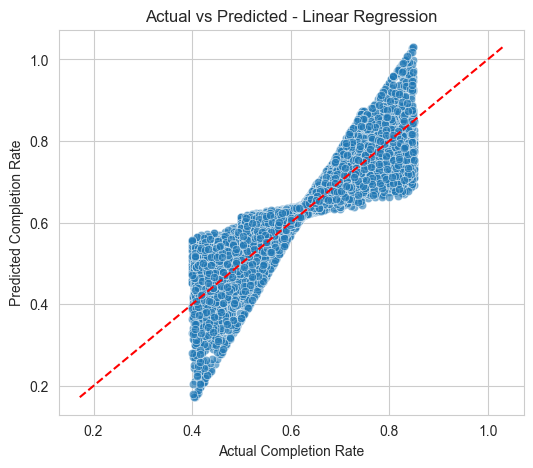

In [25]:
plt.figure(figsize=(6, 5))
sns.scatterplot(x=y_test_lin, y=y_pred_lin, alpha=0.6)
plt.xlabel("Actual Completion Rate")
plt.ylabel("Predicted Completion Rate")
plt.title("Actual vs Predicted - Linear Regression")

min_val = min(y_test_lin.min(), y_pred_lin.min())
max_val = max(y_test_lin.max(), y_pred_lin.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")
plt.show()

## Checking Residual error 

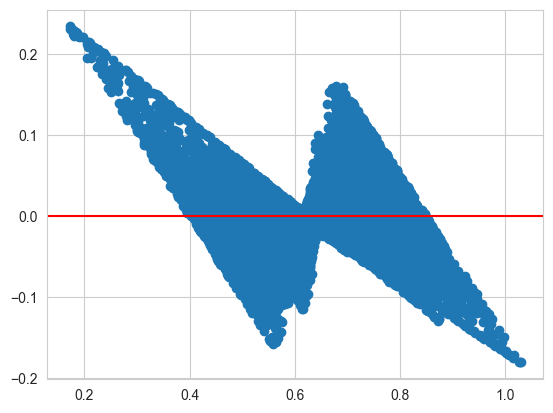

In [26]:
plt.scatter(y_pred_lin, y_test_lin - y_pred_lin)
plt.axhline(0, color='red')
plt.show()


## ✅ Conclusion

* Residuals show a V shaped pattern, suggesting variance changes with predicted values
this indicates linear regression does not fully capture nonlinear effects, 
but the model still generalizes well (R² ≈ 0.82).
- **Logistic Regression** effectively identifies viral content patterns, providing clear classification insights.  
- **Linear Regression** predicts performance metrics with strong accuracy (\(R^2 \approx 0.82\)), though residual analysis shows variance changes with predicted values, indicating some nonlinear effects remain uncaptured.  
- **Feature Engineering and Exploratory Data Analysis (EDA)** significantly improved model performance and interpretability.  
- **Limitations** include sensitivity to nonlinear relationships and potential overfitting when certain features are included.  
- **Future Work** could explore advanced models such as Random Forests, Gradient Boosting, or regularization techniques (Ridge/Lasso) to better capture complex patterns.  
- This project demonstrates a **complete ML workflow**—from EDA and feature engineering to regression modeling and evaluation—showcasing practical skills in data analytics and model development.  
- **Key takeaway:** Statistical modeling combined with thoughtful EDA can generate actionable insights for digital content performance and strategy.


This project demonstrates a complete ML workflow suitable for a **Data Analytics**.